In [2]:
from tensorflow.keras import Model, Sequential, Input
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Dropout,Reshape, Conv2DTranspose, Flatten,Conv2D
from tensorflow.keras.optimizers import Adam,RMSprop
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.regularizers import l2
from keras.callbacks import ReduceLROnPlateau

In [3]:
# 读取Excel文件中的数据
file_path = 'D:/creep rupture/TL/温度分类/重选特征/源TSdata600-700.xlsx'
data = pd.read_excel(file_path)

# 归一化数据
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values)
# 读取目标任务的数据
target_file_path = r'D:\creep rupture\TL\温度分类\重选特征\目标TSdata600-700.xlsx'
target_data = pd.read_excel(target_file_path)
# 归一化目标数据
target_scaled_data = scaler.transform(target_data.values)

In [4]:
# 定义生成器模型
def build_generator(latent_dim, output_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(BatchNormalization(momentum=0.8))
    model.add(Dense(output_dim, activation='sigmoid'))
    return model

# 定义判别器模型
def build_discriminator(input_dim):
    model = Sequential()
    model.add(Dense(512, input_dim=input_dim))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    return model
# 定义CGAN模型
def build_cgan(generator, discriminator, latent_dim):
    discriminator.trainable = True  # 判别器不可训练
    model = Sequential([generator, discriminator])
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))
    return model
# 定义外推函数
def extrapolate_data(generator, latent_dim, num_samples):
    input_data = np.random.normal(0, 1, size=(num_samples, latent_dim))
    extrapolated_data = generator.predict(input_data)
    return extrapolated_data
def train_cgan(generator, discriminator, cgan, scaled_data, epochs, batch_size, latent_dim, unfreeze_every, num_generated_samples):
    discriminator.trainable = True
    discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))

    discriminator_loss_history = []
    generator_loss_history = []
    
    total_layers = len(generator.layers)
    layers_unfrozen = 0
    
    for e in range(epochs):
        discriminator_loss = 0
        generator_loss = 0

        if e % unfreeze_every == 0 and layers_unfrozen < total_layers:
            for layer in generator.layers[:layers_unfrozen]:
                layer.trainable = True  # Unfreeze layers
            layers_unfrozen += 1
            
            # 重新编译模型以确保trainable状态的更新生效
            discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))
            cgan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0001, beta_1=0.5))
            
        d_iters = 1  # 判别器训练次数 per generator training
        for _ in range(d_iters):
            noise = np.random.normal(0, 1, size=(batch_size, latent_dim))
            generated_data = generator.predict(noise)

            real_data_index = np.random.randint(0, scaled_data.shape[0], size=batch_size)
            real_data = scaled_data[real_data_index]

            data_batch = np.concatenate([real_data, generated_data])

            labels_batch_real = np.ones((batch_size, 1)) * 0.9  # 真实样本
            labels_batch_fake = np.zeros((batch_size, 1))  # 假样本
            labels_batch = np.concatenate([labels_batch_real, labels_batch_fake])

            discriminator_loss += discriminator.train_on_batch(data_batch, labels_batch)

        noise = np.random.normal(0, 1, size=(batch_size, latent_dim))
        labels_batch = np.ones((batch_size, 1))
        generator_loss += cgan.train_on_batch(noise, labels_batch)
        
        discriminator_loss_history.append(discriminator_loss / d_iters)
        generator_loss_history.append(generator_loss)

        print(f'Epoch {e+1}/{epochs}, Discriminator Loss: {discriminator_loss}, Generator Loss: {generator_loss}')
    
    # 绘制损失曲线图
    plt.plot(range(epochs), discriminator_loss_history, label='Discriminator Loss')
    plt.plot(range(epochs), generator_loss_history, label='Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return generator

1/1 [==============================] - 0s 303ms/step
Epoch 1/300, Discriminator Loss: 0.6855278015136719, Generator Loss: 0.7150288820266724
1/1 [==============================] - 0s 40ms/step
Epoch 2/300, Discriminator Loss: 0.697035014629364, Generator Loss: 0.6956478357315063
1/1 [==============================] - 0s 29ms/step
Epoch 3/300, Discriminator Loss: 0.684256911277771, Generator Loss: 0.686195969581604
1/1 [==============================] - 0s 21ms/step
Epoch 4/300, Discriminator Loss: 0.6885925531387329, Generator Loss: 0.6623691320419312
1/1 [==============================] - 0s 21ms/step
Epoch 5/300, Discriminator Loss: 0.6869326233863831, Generator Loss: 0.6396571397781372
1/1 [==============================] - 0s 32ms/step
Epoch 6/300, Discriminator Loss: 0.6835025548934937, Generator Loss: 0.6539623737335205
1/1 [==============================] - 0s 20ms/step
Epoch 7/300, Discriminator Loss: 0.6833459138870239, Generator Loss: 0.6297581195831299
1/1 [=================

1/1 [==============================] - 0s 22ms/step
Epoch 59/300, Discriminator Loss: 0.7674336433410645, Generator Loss: 0.42194271087646484
1/1 [==============================] - 0s 24ms/step
Epoch 60/300, Discriminator Loss: 0.7536767721176147, Generator Loss: 0.43067410588264465
1/1 [==============================] - 0s 27ms/step
Epoch 61/300, Discriminator Loss: 0.7362246513366699, Generator Loss: 0.42429986596107483
1/1 [==============================] - 0s 19ms/step
Epoch 62/300, Discriminator Loss: 0.7541214227676392, Generator Loss: 0.4242152273654938
1/1 [==============================] - 0s 35ms/step
Epoch 63/300, Discriminator Loss: 0.7749329209327698, Generator Loss: 0.4226049780845642
1/1 [==============================] - 0s 24ms/step
Epoch 64/300, Discriminator Loss: 0.7780973315238953, Generator Loss: 0.41498568654060364
1/1 [==============================] - 0s 21ms/step
Epoch 65/300, Discriminator Loss: 0.7789340019226074, Generator Loss: 0.40808698534965515
1/1 [===

1/1 [==============================] - 0s 21ms/step
Epoch 117/300, Discriminator Loss: 0.8122504949569702, Generator Loss: 0.36907559633255005
1/1 [==============================] - 0s 21ms/step
Epoch 118/300, Discriminator Loss: 0.8208999633789062, Generator Loss: 0.35257387161254883
1/1 [==============================] - 0s 30ms/step
Epoch 119/300, Discriminator Loss: 0.8217030763626099, Generator Loss: 0.3649328052997589
1/1 [==============================] - 0s 20ms/step
Epoch 120/300, Discriminator Loss: 0.8632316589355469, Generator Loss: 0.37324684858322144
1/1 [==============================] - 0s 31ms/step
Epoch 121/300, Discriminator Loss: 0.7994995713233948, Generator Loss: 0.3690992593765259
1/1 [==============================] - 0s 38ms/step
Epoch 122/300, Discriminator Loss: 0.824945867061615, Generator Loss: 0.3702693283557892
1/1 [==============================] - 0s 34ms/step
Epoch 123/300, Discriminator Loss: 0.8471874594688416, Generator Loss: 0.37155547738075256
1/1

Epoch 174/300, Discriminator Loss: 0.8463802337646484, Generator Loss: 0.33505746722221375
1/1 [==============================] - 0s 27ms/step
Epoch 175/300, Discriminator Loss: 0.8174469470977783, Generator Loss: 0.35143181681632996
1/1 [==============================] - 0s 32ms/step
Epoch 176/300, Discriminator Loss: 0.853420615196228, Generator Loss: 0.32971668243408203
1/1 [==============================] - 0s 39ms/step
Epoch 177/300, Discriminator Loss: 0.8593685626983643, Generator Loss: 0.35406798124313354
1/1 [==============================] - 0s 31ms/step
Epoch 178/300, Discriminator Loss: 0.8226523399353027, Generator Loss: 0.34263768792152405
1/1 [==============================] - 0s 43ms/step
Epoch 179/300, Discriminator Loss: 0.8391504287719727, Generator Loss: 0.3559108376502991
1/1 [==============================] - 0s 23ms/step
Epoch 180/300, Discriminator Loss: 0.7939525842666626, Generator Loss: 0.35678374767303467
1/1 [==============================] - 0s 23ms/step
E

1/1 [==============================] - 0s 35ms/step
Epoch 232/300, Discriminator Loss: 0.8257936239242554, Generator Loss: 0.3459395170211792
1/1 [==============================] - 0s 38ms/step
Epoch 233/300, Discriminator Loss: 0.8216280937194824, Generator Loss: 0.3372594118118286
1/1 [==============================] - 0s 20ms/step
Epoch 234/300, Discriminator Loss: 0.8535188436508179, Generator Loss: 0.3416820466518402
1/1 [==============================] - 0s 30ms/step
Epoch 235/300, Discriminator Loss: 0.8720870018005371, Generator Loss: 0.3624569773674011
1/1 [==============================] - 0s 20ms/step
Epoch 236/300, Discriminator Loss: 0.8575347661972046, Generator Loss: 0.32685714960098267
1/1 [==============================] - 0s 21ms/step
Epoch 237/300, Discriminator Loss: 0.8732693195343018, Generator Loss: 0.35274600982666016
1/1 [==============================] - 0s 41ms/step
Epoch 238/300, Discriminator Loss: 0.8604010343551636, Generator Loss: 0.3349529802799225
1/1 

1/1 [==============================] - 0s 26ms/step
Epoch 290/300, Discriminator Loss: 0.832584023475647, Generator Loss: 0.3425692617893219
1/1 [==============================] - 0s 19ms/step
Epoch 291/300, Discriminator Loss: 0.8655408024787903, Generator Loss: 0.3448806405067444
1/1 [==============================] - 0s 29ms/step
Epoch 292/300, Discriminator Loss: 0.8402791023254395, Generator Loss: 0.3544926047325134
1/1 [==============================] - 0s 28ms/step
Epoch 293/300, Discriminator Loss: 0.8716521859169006, Generator Loss: 0.32810166478157043
1/1 [==============================] - 0s 42ms/step
Epoch 294/300, Discriminator Loss: 0.8647491335868835, Generator Loss: 0.33785730600357056
1/1 [==============================] - 0s 22ms/step
Epoch 295/300, Discriminator Loss: 0.846937358379364, Generator Loss: 0.3260686695575714
1/1 [==============================] - 0s 24ms/step
Epoch 296/300, Discriminator Loss: 0.852532148361206, Generator Loss: 0.32176369428634644
1/1 [=

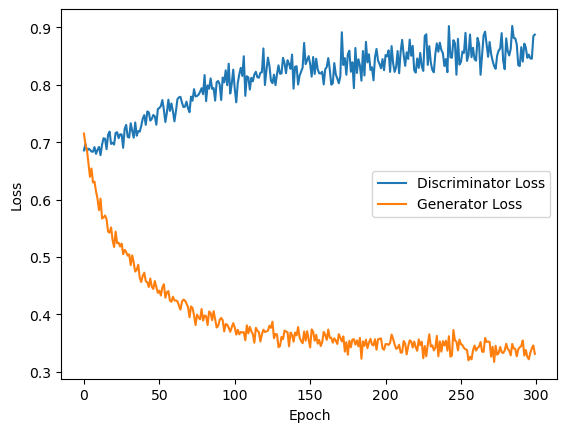

1/1 [==============================] - 0s 160ms/step
外推结果已保存到: D:\creep rupture\TL\温度分类\重选特征\源TSdata600-700CGAN+TL.xlsx


In [5]:
# 参数设置
latent_dim = 200
epochs = 300
batch_size = 32
unfreeze_every = 9
num_generated_samples=20

# 获取输入和输出维度
input_dim = scaled_data.shape[1]  # 输入维度
output_dim = 10 # 输出维度

# 构建生成器和判别器
generator = build_generator(latent_dim, output_dim)
discriminator = build_discriminator(input_dim)

# 构建CGAN模型
cgan = build_cgan(generator,discriminator, latent_dim)

# 训练CGAN模型
generator = train_cgan(generator, discriminator, cgan, scaled_data, epochs, batch_size, latent_dim, unfreeze_every, num_generated_samples)

# 使用训练后的生成器产生外推数据
extrapolated_data = extrapolate_data(generator, latent_dim, num_generated_samples)

# 将外推数据逆归一化
extrapolated_data = scaler.inverse_transform(extrapolated_data)

# 将外推数据保存到Excel文件
extrapolated_df = pd.DataFrame(extrapolated_data, columns=data.columns)
output_file_path = r'D:\creep rupture\TL\温度分类\重选特征\源TSdata600-700CGAN+TL.xlsx'
extrapolated_df.to_excel(output_file_path, index=False)
print("外推结果已保存到:", output_file_path)

1/1 [==============================] - 0s 150ms/step
Epoch 1/300, Discriminator Loss: 0.6812780499458313, Generator Loss: 0.7673934698104858
1/1 [==============================] - 0s 21ms/step
Epoch 2/300, Discriminator Loss: 0.6895668506622314, Generator Loss: 0.7310429215431213
1/1 [==============================] - 0s 21ms/step
Epoch 3/300, Discriminator Loss: 0.6748141050338745, Generator Loss: 0.7326167225837708
1/1 [==============================] - 0s 35ms/step
Epoch 4/300, Discriminator Loss: 0.6711612939834595, Generator Loss: 0.7270123362541199
1/1 [==============================] - 0s 53ms/step
Epoch 5/300, Discriminator Loss: 0.6775807738304138, Generator Loss: 0.7252682447433472
1/1 [==============================] - 0s 33ms/step
Epoch 6/300, Discriminator Loss: 0.669712483882904, Generator Loss: 0.6942048072814941
1/1 [==============================] - 0s 19ms/step
Epoch 7/300, Discriminator Loss: 0.6835066080093384, Generator Loss: 0.6953834295272827
1/1 [===============

1/1 [==============================] - 0s 18ms/step
Epoch 59/300, Discriminator Loss: 0.695884644985199, Generator Loss: 0.49083012342453003
1/1 [==============================] - 0s 25ms/step
Epoch 60/300, Discriminator Loss: 0.6699119210243225, Generator Loss: 0.48582395911216736
1/1 [==============================] - 0s 36ms/step
Epoch 61/300, Discriminator Loss: 0.6249558925628662, Generator Loss: 0.48318248987197876
1/1 [==============================] - 0s 21ms/step
Epoch 62/300, Discriminator Loss: 0.7273995876312256, Generator Loss: 0.493629515171051
1/1 [==============================] - 0s 20ms/step
Epoch 63/300, Discriminator Loss: 0.6952781677246094, Generator Loss: 0.4714551270008087
1/1 [==============================] - 0s 27ms/step
Epoch 64/300, Discriminator Loss: 0.6932130455970764, Generator Loss: 0.48113399744033813
1/1 [==============================] - 0s 29ms/step
Epoch 65/300, Discriminator Loss: 0.7313123941421509, Generator Loss: 0.5064495801925659
1/1 [======

Epoch 116/300, Discriminator Loss: 0.7706739902496338, Generator Loss: 0.4374387264251709
1/1 [==============================] - 0s 33ms/step
Epoch 117/300, Discriminator Loss: 0.7311954498291016, Generator Loss: 0.4532843232154846
1/1 [==============================] - 0s 20ms/step
Epoch 118/300, Discriminator Loss: 0.7311451435089111, Generator Loss: 0.4275478422641754
1/1 [==============================] - 0s 22ms/step
Epoch 119/300, Discriminator Loss: 0.7720345258712769, Generator Loss: 0.414733350276947
1/1 [==============================] - 0s 19ms/step
Epoch 120/300, Discriminator Loss: 0.7677000761032104, Generator Loss: 0.44935745000839233
1/1 [==============================] - 0s 18ms/step
Epoch 121/300, Discriminator Loss: 0.7137504816055298, Generator Loss: 0.4405239224433899
1/1 [==============================] - 0s 20ms/step
Epoch 122/300, Discriminator Loss: 0.7869597673416138, Generator Loss: 0.4432412385940552
1/1 [==============================] - 0s 20ms/step
Epoch 

1/1 [==============================] - 0s 35ms/step
Epoch 174/300, Discriminator Loss: 0.7803777456283569, Generator Loss: 0.41912806034088135
1/1 [==============================] - 0s 27ms/step
Epoch 175/300, Discriminator Loss: 0.7062572836875916, Generator Loss: 0.43181705474853516
1/1 [==============================] - 0s 20ms/step
Epoch 176/300, Discriminator Loss: 0.8015426397323608, Generator Loss: 0.4375970959663391
1/1 [==============================] - 0s 22ms/step
Epoch 177/300, Discriminator Loss: 0.7804142236709595, Generator Loss: 0.426027774810791
1/1 [==============================] - 0s 32ms/step
Epoch 178/300, Discriminator Loss: 0.7883261442184448, Generator Loss: 0.44864970445632935
1/1 [==============================] - 0s 21ms/step
Epoch 179/300, Discriminator Loss: 0.7570236325263977, Generator Loss: 0.4218831956386566
1/1 [==============================] - 0s 25ms/step
Epoch 180/300, Discriminator Loss: 0.7704797983169556, Generator Loss: 0.410692036151886
1/1 [

Epoch 231/300, Discriminator Loss: 0.7592881917953491, Generator Loss: 0.42345377802848816
1/1 [==============================] - 0s 18ms/step
Epoch 232/300, Discriminator Loss: 0.7585891485214233, Generator Loss: 0.43130630254745483
1/1 [==============================] - 0s 18ms/step
Epoch 233/300, Discriminator Loss: 0.7245350480079651, Generator Loss: 0.4282749891281128
1/1 [==============================] - 0s 19ms/step
Epoch 234/300, Discriminator Loss: 0.7429516315460205, Generator Loss: 0.4396609961986542
1/1 [==============================] - 0s 21ms/step
Epoch 235/300, Discriminator Loss: 0.7808614373207092, Generator Loss: 0.42897123098373413
1/1 [==============================] - 0s 22ms/step
Epoch 236/300, Discriminator Loss: 0.7328469157218933, Generator Loss: 0.40720975399017334
1/1 [==============================] - 0s 26ms/step
Epoch 237/300, Discriminator Loss: 0.7613407373428345, Generator Loss: 0.4110649824142456
1/1 [==============================] - 0s 33ms/step
Ep

1/1 [==============================] - 0s 21ms/step
Epoch 289/300, Discriminator Loss: 0.7741721868515015, Generator Loss: 0.41475820541381836
1/1 [==============================] - 0s 42ms/step
Epoch 290/300, Discriminator Loss: 0.7375643253326416, Generator Loss: 0.4171237051486969
1/1 [==============================] - 0s 31ms/step
Epoch 291/300, Discriminator Loss: 0.7596450448036194, Generator Loss: 0.40737807750701904
1/1 [==============================] - 0s 26ms/step
Epoch 292/300, Discriminator Loss: 0.8154687881469727, Generator Loss: 0.42044150829315186
1/1 [==============================] - 0s 20ms/step
Epoch 293/300, Discriminator Loss: 0.7390702962875366, Generator Loss: 0.4136696457862854
1/1 [==============================] - 0s 19ms/step
Epoch 294/300, Discriminator Loss: 0.7464112043380737, Generator Loss: 0.41763216257095337
1/1 [==============================] - 0s 21ms/step
Epoch 295/300, Discriminator Loss: 0.7661838531494141, Generator Loss: 0.3832906484603882
1/

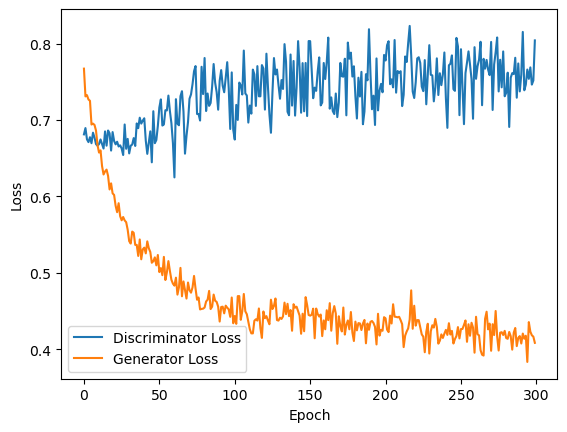

1/1 [==============================] - 0s 150ms/step
目标任务的外推结果已保存到: D:\creep rupture\TL\温度分类\重选特征\目标TSdata600-700CGAN+TL.xlsx


In [6]:
# Initialize the target_generator with weights transferred from the source task's generator
target_generator = build_generator(latent_dim, output_dim)  # Build using the same architecture
target_generator.set_weights(generator.get_weights())  # Transfer weights

# Note: If the discriminator also needs adaptation, consider re-initializing it and training from scratch or fine-tuning

# Initialize a discriminator for the target task if needed (can be a fresh one or same with fine-tuning)
target_discriminator = build_discriminator(input_dim)  # Reuse or rebuild based on the target task needs

# Reinitialize or reuse the CGAN model with the target task components
target_cgan = build_cgan(target_generator, target_discriminator, latent_dim)

# Train on the target task data
target_generator = train_cgan(target_generator, target_discriminator, target_cgan, target_scaled_data, epochs, batch_size, latent_dim, unfreeze_every, num_generated_samples)

# Extrapolating and processing target task data
target_extrapolated_data = extrapolate_data(target_generator, latent_dim, num_generated_samples)
target_extrapolated_data = scaler.inverse_transform(target_extrapolated_data)  # Ensure 'scaler' is fit on target task data

# Formatting and saving the extrapolated data for the target task
target_extrapolated_df = pd.DataFrame(target_extrapolated_data, columns=target_data.columns)
target_output_file_path = r'D:\creep rupture\TL\温度分类\重选特征\目标TSdata600-700CGAN+TL.xlsx'
target_extrapolated_df.to_excel(target_output_file_path, index=False)
print("目标任务的外推结果已保存到:", target_output_file_path)

1/1 [==============================] - 0s 20ms/step
Epoch 1/300, Discriminator Loss: 0.8043220043182373, Generator Loss: 0.436196506023407
1/1 [==============================] - 0s 22ms/step
Epoch 2/300, Discriminator Loss: 0.7485098838806152, Generator Loss: 0.4028501510620117
1/1 [==============================] - 0s 19ms/step
Epoch 3/300, Discriminator Loss: 0.7709823846817017, Generator Loss: 0.4006478786468506
1/1 [==============================] - 0s 19ms/step
Epoch 4/300, Discriminator Loss: 0.8297857046127319, Generator Loss: 0.40234941244125366
1/1 [==============================] - 0s 23ms/step
Epoch 5/300, Discriminator Loss: 0.7870209217071533, Generator Loss: 0.41568225622177124
1/1 [==============================] - 0s 26ms/step
Epoch 6/300, Discriminator Loss: 0.738364577293396, Generator Loss: 0.4282792806625366
1/1 [==============================] - 0s 20ms/step
Epoch 7/300, Discriminator Loss: 0.7827311754226685, Generator Loss: 0.3950669765472412
1/1 [===============

1/1 [==============================] - 0s 19ms/step
Epoch 59/300, Discriminator Loss: 0.7687634229660034, Generator Loss: 0.3897630274295807
1/1 [==============================] - 0s 28ms/step
Epoch 60/300, Discriminator Loss: 0.7854877710342407, Generator Loss: 0.41359743475914
1/1 [==============================] - 0s 31ms/step
Epoch 61/300, Discriminator Loss: 0.8076781630516052, Generator Loss: 0.38365381956100464
1/1 [==============================] - 0s 35ms/step
Epoch 62/300, Discriminator Loss: 0.8254561424255371, Generator Loss: 0.40077537298202515
1/1 [==============================] - 0s 21ms/step
Epoch 63/300, Discriminator Loss: 0.8196812868118286, Generator Loss: 0.41043537855148315
1/1 [==============================] - 0s 41ms/step
Epoch 64/300, Discriminator Loss: 0.7933081984519958, Generator Loss: 0.39698755741119385
1/1 [==============================] - 0s 19ms/step
Epoch 65/300, Discriminator Loss: 0.7757296562194824, Generator Loss: 0.40813958644866943
1/1 [=====

1/1 [==============================] - 0s 42ms/step
Epoch 117/300, Discriminator Loss: 0.8262109756469727, Generator Loss: 0.36654913425445557
1/1 [==============================] - 0s 39ms/step
Epoch 118/300, Discriminator Loss: 0.7951276302337646, Generator Loss: 0.3739405870437622
1/1 [==============================] - 0s 37ms/step
Epoch 119/300, Discriminator Loss: 0.8209811449050903, Generator Loss: 0.3773350119590759
1/1 [==============================] - 0s 21ms/step
Epoch 120/300, Discriminator Loss: 0.813521683216095, Generator Loss: 0.36253654956817627
1/1 [==============================] - 0s 22ms/step
Epoch 121/300, Discriminator Loss: 0.8057214617729187, Generator Loss: 0.37502753734588623
1/1 [==============================] - 0s 19ms/step
Epoch 122/300, Discriminator Loss: 0.7972939610481262, Generator Loss: 0.35642358660697937
1/1 [==============================] - 0s 35ms/step
Epoch 123/300, Discriminator Loss: 0.8066720962524414, Generator Loss: 0.3497726023197174
1/1

Epoch 174/300, Discriminator Loss: 0.8128142356872559, Generator Loss: 0.35366761684417725
1/1 [==============================] - 0s 43ms/step
Epoch 175/300, Discriminator Loss: 0.8551088571548462, Generator Loss: 0.3530508875846863
1/1 [==============================] - 0s 37ms/step
Epoch 176/300, Discriminator Loss: 0.8034778833389282, Generator Loss: 0.37906017899513245
1/1 [==============================] - 0s 18ms/step
Epoch 177/300, Discriminator Loss: 0.8132902383804321, Generator Loss: 0.3840043544769287
1/1 [==============================] - 0s 37ms/step
Epoch 178/300, Discriminator Loss: 0.8387914896011353, Generator Loss: 0.3606792688369751
1/1 [==============================] - 0s 40ms/step
Epoch 179/300, Discriminator Loss: 0.7978721857070923, Generator Loss: 0.35884374380111694
1/1 [==============================] - 0s 19ms/step
Epoch 180/300, Discriminator Loss: 0.8165715932846069, Generator Loss: 0.3545615077018738
1/1 [==============================] - 0s 19ms/step
Epo

Epoch 231/300, Discriminator Loss: 0.8401453495025635, Generator Loss: 0.3531986474990845
1/1 [==============================] - 0s 25ms/step
Epoch 232/300, Discriminator Loss: 0.8347362279891968, Generator Loss: 0.3509175181388855
1/1 [==============================] - 0s 22ms/step
Epoch 233/300, Discriminator Loss: 0.7953064441680908, Generator Loss: 0.37009644508361816
1/1 [==============================] - 0s 42ms/step
Epoch 234/300, Discriminator Loss: 0.8149986267089844, Generator Loss: 0.35979512333869934
1/1 [==============================] - 0s 35ms/step
Epoch 235/300, Discriminator Loss: 0.8526560664176941, Generator Loss: 0.367094486951828
1/1 [==============================] - 0s 27ms/step
Epoch 236/300, Discriminator Loss: 0.8030681610107422, Generator Loss: 0.3608782887458801
1/1 [==============================] - 0s 35ms/step
Epoch 237/300, Discriminator Loss: 0.8114759922027588, Generator Loss: 0.35229602456092834
1/1 [==============================] - 0s 36ms/step
Epoc

1/1 [==============================] - 0s 21ms/step
Epoch 289/300, Discriminator Loss: 0.8482562303543091, Generator Loss: 0.3548973798751831
1/1 [==============================] - 0s 20ms/step
Epoch 290/300, Discriminator Loss: 0.8132065534591675, Generator Loss: 0.3637760579586029
1/1 [==============================] - 0s 37ms/step
Epoch 291/300, Discriminator Loss: 0.8295393586158752, Generator Loss: 0.36270689964294434
1/1 [==============================] - 0s 25ms/step
Epoch 292/300, Discriminator Loss: 0.8012256622314453, Generator Loss: 0.35429298877716064
1/1 [==============================] - 0s 61ms/step
Epoch 293/300, Discriminator Loss: 0.790756106376648, Generator Loss: 0.35941052436828613
1/1 [==============================] - 0s 43ms/step
Epoch 294/300, Discriminator Loss: 0.8094480633735657, Generator Loss: 0.3317033648490906
1/1 [==============================] - 0s 21ms/step
Epoch 295/300, Discriminator Loss: 0.8230879306793213, Generator Loss: 0.3633294999599457
1/1 

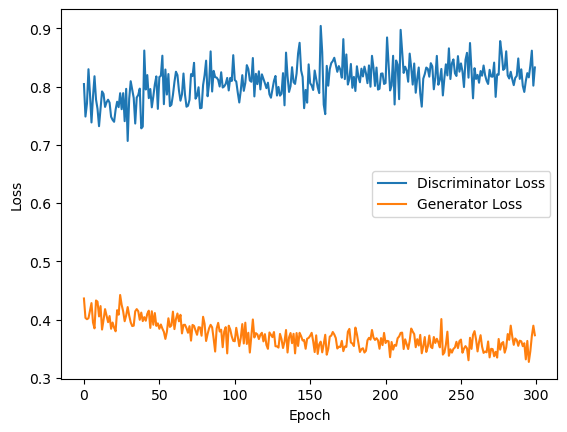

1/1 [==============================] - 0s 21ms/step
微调后的目标任务外推结果已保存到: D:\creep rupture\TL\温度分类\重选特征\微调目标TSdata600-700CGAN+TL.xlsx


In [7]:
def fine_tune_generator(generator, discriminator, target_scaled_data, epochs, batch_size, latent_dim, unfreeze_layers_step, unfreeze_every, num_generated_samples):
    # This unfreeze_layers_step variable is added to control how many layers to unfreeze each time
    total_layers = len(generator.layers)
    layers_unfrozen = 0
    
    for e in range(epochs):
        # Gradually unfreeze layers according to the specified step
        if e % unfreeze_every == 0 and layers_unfrozen < total_layers:
            for layer in generator.layers[-(layers_unfrozen+unfreeze_layers_step):]:
                layer.trainable = True
            layers_unfrozen += unfreeze_layers_step
            
            # Re-compile models to apply the trainable changes
            discriminator.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
            fine_tune_gan = build_cgan(generator, discriminator, latent_dim)
            fine_tune_gan.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
        
        # Continue training as usual here...

    train_cgan(generator, discriminator, fine_tune_gan, target_scaled_data, epochs, batch_size, latent_dim, unfreeze_every, num_generated_samples)
    return generator

# 微调生成器，确保正确传递所有需要的参数，特别是num_generated_samples
fine_tuned_generator = fine_tune_generator(target_generator, target_discriminator, target_scaled_data, epochs, batch_size, latent_dim, unfreeze_layers_step=1, unfreeze_every=unfreeze_every, num_generated_samples=num_generated_samples)

# Generate target task's extrapolated data, ensure passing `num_generated_samples`
target_fine_tuned_extrapolated_data = extrapolate_data(fine_tuned_generator, latent_dim, num_generated_samples)

# Make sure your data transformation and concatenation logic fits your specific use case
target_fine_tuned_extrapolated_data = scaler.inverse_transform(target_fine_tuned_extrapolated_data)
# 将微调后的目标任务的外推数据保存到Excel文件
target_fine_tuned_extrapolated_df = pd.DataFrame(target_fine_tuned_extrapolated_data, columns=target_data.columns)
target_fine_tuned_output_file_path = r'D:\creep rupture\TL\温度分类\重选特征\微调目标TSdata600-700CGAN+TL.xlsx'
target_fine_tuned_extrapolated_df.to_excel(target_fine_tuned_output_file_path, index=False)
print("微调后的目标任务外推结果已保存到:", target_fine_tuned_output_file_path)